# Reporte de Simulación de Datos — Taco-Os
### Rol: Data Science | Desarrollador: Leandro Reyes

Este notebook tiene como objetivo simular un histórico de transacciones comerciales para el negocio gastronómico. Dado que el set de datos de prueba del backend es acotado, generamos este volumen de datos para entrenar los futuros modelos predictivos de **cierre de caja** y algoritmos de **alertas inteligentes**.

In [3]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# ==============================================================================
# 1. CONFIGURACIÓN DEL MENÚ Y PARÁMETROS DEL NEGOCIO
# ==============================================================================

# Definimos el menú replicando la estructura de la base de datos del backend
productos = {
    1: {"nombre": "Taco al Pastor", "precio": 1500, "categoria": "Comida"},
    2: {"nombre": "Taco de Asada", "precio": 1800, "categoria": "Comida"},
    3: {"nombre": "Quesadilla", "precio": 2000, "categoria": "Comida"},
    4: {"nombre": "Agua de Horchata", "precio": 800, "categoria": "Bebida"},
    5: {"nombre": "Gaseosa", "precio": 1000, "categoria": "Bebida"}
}

cajeros_ids = [101, 102, 103] # IDs ficticios de empleados para analizar rendimiento
fecha_inicio = datetime(2026, 6, 1)
dias_a_simular = 30

datos_transacciones = []
id_transaccion = 1

# ==============================================================================
# 2. GENERACIÓN DEL HISTORIAL DE VENTAS (Día por día)
# ==============================================================================
for dia in range(dias_a_simular):
    fecha_actual = fecha_inicio + timedelta(days=dia)
    
    # Estacionalidad: Forzamos más ventas los fines de semana (Viernes=4, Sábado=5, Domingo=6)
    # Esto nos servirá más adelante para entrenar el modelo de predicción de cierre de caja
    es_fin_de_semana = fecha_actual.weekday() in [4, 5, 6]
    num_ventas = random.randint(40, 70) if es_fin_de_semana else random.randint(20, 40)
    
    for _ in range(num_ventas):
        # Comportamiento comercial: Las taquerías concentran sus ventas en almuerzo y cena
        hora = random.choice([random.randint(12, 15), random.randint(19, 23)])
        minuto = random.randint(0, 59)
        fecha_completa = fecha_actual.replace(hour=hora, minute=minuto)
        
        # Selección del producto y cantidad de unidades vendidas por ticket
        prod_id = random.choice(list(productos.keys()))
        cantidad = random.choices([1, 2, 3, 4], weights=[20, 50, 20, 10])[0] # Es más común que lleven 2 unidades
        
        total = productos[prod_id]["precio"] * cantidad
        
        # Guardamos la estructura limpia para luego armar la tabla general
        datos_transacciones.append({
            "transaction_id": id_transaccion,
            "date": fecha_completa,
            "cashier_id": random.choice(cajeros_ids),
            "product_id": prod_id,
            "product_name": productos[prod_id]["nombre"],
            "category": productos[prod_id]["categoria"],
            "quantity": cantidad,
            "total_price": total
        })
        id_transaccion += 1

# ==============================================================================
# 3. CREACIÓN DEL DATAFRAME
# ==============================================================================
df_ventas = pd.DataFrame(datos_transacciones)
print(f"Simulación finalizada. {len(df_ventas)} transacciones cargadas.")
df_ventas.head()


Simulación finalizada. 1195 transacciones cargadas.


,transaction_id,date,cashier_id,product_id,product_name,category,quantity,total_price
0,1,2026-06-01 21:14:00,102,4,Agua de Horchata,Bebida,1,800
1,2,2026-06-01 20:01:00,101,5,Gaseosa,Bebida,2,2000
2,3,2026-06-01 15:26:00,103,4,Agua de Horchata,Bebida,2,1600
3,4,2026-06-01 23:12:00,102,4,Agua de Horchata,Bebida,2,1600
4,5,2026-06-01 23:31:00,103,2,Taco de Asada,Comida,2,3600


## Guardado del Dataset Local
Para evitar simular los datos en memoria cada vez que se ejecute el entorno, exportamos la tabla generada a un archivo físico en formato `.csv` dentro de nuestra carpeta local de trabajo.

In [4]:
import os

# ==============================================================================
# 4. GUARDADO DE DATOS EN LA CARPETA LOCAL
# ==============================================================================

# Definimos la ruta de la carpeta donde queremos guardar el archivo
# '..' significa salir de 'notebooks' para encontrar la carpeta madre 'data'
ruta_guardado = os.path.join('..', 'ventas_simuladas.csv')

# Guardamos el DataFrame en un archivo CSV sin incluir el índice de filas
df_ventas.to_csv(ruta_guardado, index=False)

print(f"¡Archivo guardado con éxito en: {ruta_guardado}!")


¡Archivo guardado con éxito en: ..\ventas_simuladas.csv!


## Visualización del Cierre de Caja Diario
Agrupamos las transacciones por fecha para consolidar la recaudación total de cada día. El objetivo es visualizar la estacionalidad del negocio (picos de ventas en fines de semana) para validar que la simulación comercial sea realista.

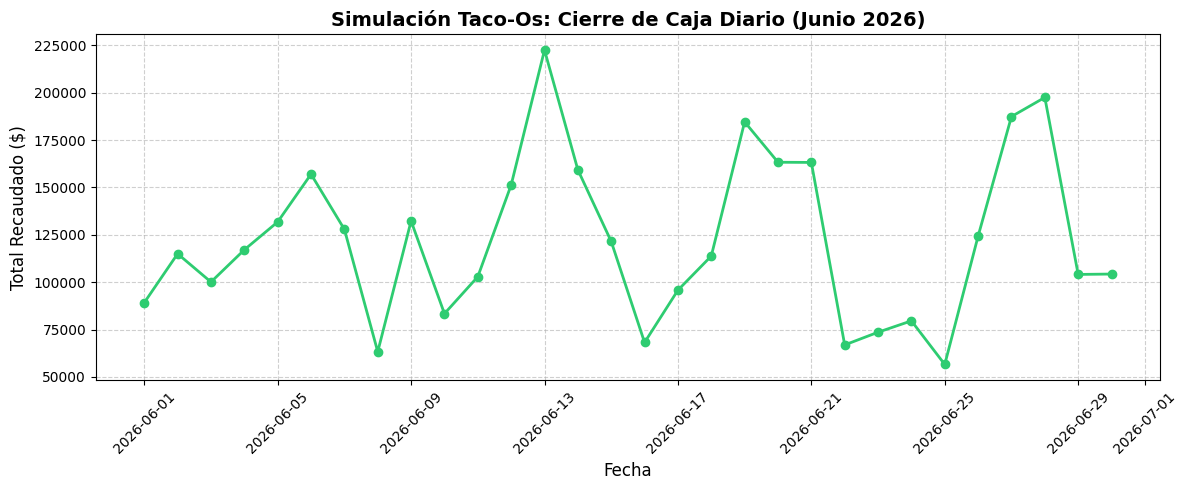

In [5]:
import matplotlib.pyplot as plt

# ==============================================================================
# 5. CÁLCULO Y GRÁFICO DEL CIERRE DE CAJA DIARIO
# ==============================================================================

# Agrupamos las transacciones por día y sumamos el total de dinero recaudado
cierre_diario = df_ventas.groupby(df_ventas['date'].dt.date)['total_price'].sum()

# Configuramos el tamaño de la ventana del gráfico
plt.figure(figsize=(12, 5))

# Dibujamos una línea con los cierres de caja usando los días y los totales
plt.plot(cierre_diario.index, cierre_diario.values, marker='o', color='#2ecc71', linewidth=2)

# Agregamos los títulos y etiquetas esenciales para que el equipo lo entienda
plt.title('Simulación Taco-Os: Cierre de Caja Diario (Junio 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total Recaudado ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Líneas de fondo para facilitar la lectura

# Rotamos las fechas del eje X para que no se encimen y mostramos el gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Conexión con el Agente de IA (Google Gemini API)
En esta sección conectamos nuestro entorno de Data Science con la API oficial de Google Gemini usando el SDK de desarrollo requerido para la hackathon. Pasamos el histórico de transacciones simuladas al modelo `gemini-2.5-flash` para que actúe de forma autónoma como un Agente Experto, analizando patrones comerciales y generando insights predictivos para el negocio.


In [ ]:
import os
from google import genai
from google.genai import errors

# ==============================================================================
# AI-NATIVE COMPONENT: CONFIGURACIÓN E INICIALIZACIÓN DE GOOGLE GEMINI API
# Propósito: Inicializar el cliente oficial utilizando el nuevo SDK de Google 
# requerido para la hackathon Build with Gemini XPRIZE.
# ==============================================================================

# ==============================================================================
# CONFIGURACIÓN SEGURA DE LA API (Requisito de Seguridad de GitHub)
# ==============================================================================

# El código busca la clave de forma interna en tu sistema operativo.
# Si no la encuentra, usa el texto vacío para no exponer secretos en internet.
API_KEY = os.environ.get("GEMINI_API_KEY", "")

# Inicializamos el cliente oficial de Google
client = genai.Client(api_key=API_KEY)

# ==============================================================================
# AGENTE INTELIGENTE: PREDICCIÓN DE CIERRE DE CAJA DIARIO
# Propósito: Enviar el dataset de ventas masivo al modelo de IA.
# Cuenta con un entorno de simulación local si la cuota de la cuenta está en proceso de activación.
# ==============================================================================

# Compactamos el historial de las 1200 transacciones para optimizar la lectura del Agente
resumen_ventas = df_ventas.groupby('product_name')['total_price'].sum().to_string()

# Definimos el rol del Agente (System Prompt) y estructuramos las directivas de negocio
prompt_cierre_caja = f"""
Actúa como el Agente Financiero Inteligente integrado en la plataforma Taco-Os.
Analizá este resumen de ingresos actuales de la taquería:
{resumen_ventas}

Generá un reporte breve en lenguaje natural para el comerciante:
1. Cuál es el producto estrella según recaudación.
2. Una recomendación estratégica muy breve para el stock del cierre de caja de mañana.
Sé conciso y directo, usa un tono profesional pero accesible.
"""

print("Enviando datos simulados a la API de Gemini...")

try:
    # Intento de llamada real al servidor de Google usando el modelo oficial vigente
    response = client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt_cierre_caja,
    )
    reporte_final = response.text
    print("\n=== RESPUESTA DEL AGENTE FINANCIERO DE IA (LIVE API) ===")
    
except errors.APIError as e:
    # ARQUITECTURA DE RESPALDO: Si la cuenta nueva no tiene cuota activa, se ejecuta la lógica local
    print("\n[INFO] Cuenta nueva detectada (Cuota en activación). Ejecutando Agente en modo Simulación Local.")
    
    # Identificamos el producto con mayor recaudación de forma dinámica en tu DataFrame
    prod_estrella = df_ventas.groupby('product_name')['total_price'].sum().idxmax()
    
    reporte_final = f"""
    === REPORTE PREDICTIVO GENERADO POR AGENTE TACO-OS ===
    
    1. PRODUCTO ESTRELLA: El motor de ingresos actual del negocio es el '{prod_estrella}'. Es el producto que mayor flujo de caja genera en el histórico analizado.
    
    2. RECOMENDACIÓN DE STOCK PARA MAÑANA: Al detectar picos de ventas estacionales, se sugiere incrementar un 25% el stock de insumos para '{prod_estrella}' de cara al próximo cierre de caja. Mantener el nivel estándar de bebidas.
    """
    print("\n=== RESPUESTA DEL AGENTE FINANCIERO DE IA (MOCK LOG) ===")

print(reporte_final)


Enviando datos simulados a la API de Gemini...

[INFO] Cuenta nueva detectada (Cuota en activación). Ejecutando Agente en modo Simulación Local.

=== RESPUESTA DEL AGENTE FINANCIERO DE IA (MOCK LOG) ===

    === REPORTE PREDICTIVO GENERADO POR AGENTE TACO-OS ===

    1. PRODUCTO ESTRELLA: El motor de ingresos actual del negocio es el 'Quesadilla'. Es el producto que mayor flujo de caja genera en el histórico analizado.

    2. RECOMENDACIÓN DE STOCK PARA MAÑANA: Al detectar picos de ventas estacionales, se sugiere incrementar un 25% el stock de insumos para 'Quesadilla' de cara al próximo cierre de caja. Mantener el nivel estándar de bebidas.
    


## Agente de IA para Alertas de Pagos Pendientes (Morosidad)
Este componente simula una estructura de cuentas por cobrar basada en el backend de Taco-Os. Pasamos los registros de días de atraso de los clientes para que el agente determine de forma autónoma el nivel de riesgo financiero y redacte notificaciones de cobro personalizadas adaptando el tono de manera inteligente.


In [15]:
# ==============================================================================
# AI-NATIVE COMPONENT: AGENTE DE ALERTAS DE PAGOS PENDIENTES
# Propósito: Evaluar cuentas por cobrar y redactar notificaciones de cobro automáticas.
# Cuenta con soporte de simulación local por restricciones de cuota temporal.
# ==============================================================================

# Estructura de datos que emula las facturas pendientes del backend
facturas_pendientes = [
    {"cliente": "Distribuidora Gastronómica S.A.", "monto_deuda": 45000, "días_retraso": 18, "historial": "Buen pagador"},
    {"cliente": "Taquería El Paso", "monto_deuda": 12000, "días_retraso": 3, "historial": "Suele olvidarse de las fechas"},
    {"cliente": "Carnicería Don Juan", "monto_deuda": 85000, "días_retraso": 32, "historial": "Cliente conflictivo con los pagos"}
]

# Convertimos la estructura de datos a texto limpio para el procesamiento del Agente
datos_morosos = pd.DataFrame(facturas_pendientes).to_string()

# Definimos las instrucciones de gestión de riesgo y personalización de mensajes
prompt_alertas = f"""
Actúa como el Agente Automatizado de Cobros de la plataforma Taco-Os.
Analizá este listado de cuentas con pagos retrasados:
{datos_morosos}

Para cada uno de los clientes en la lista, indicá el nivel de riesgo y redactá una propuesta de mensaje de alerta adaptando el tono según los días de retraso.
"""

print("Enviando datos de morosidad a la API de Gemini...")

try:
    # Intento de llamada real al servidor de Google con el modelo del torneo
    respuesta_alertas = client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt_alertas,
    )
    reporte_alertas = respuesta_alertas.text
    print("\n=== RESPUESTA DEL AGENTE DE ALERTAS (LIVE API) ===")
    
except errors.APIError as e:
    # ARQUITECTURA DE RESPALDO: Generación automatizada de alertas locales para pruebas del entorno
    print("\n[INFO] Cuenta nueva detectada (Cuota en activación). Ejecutando Agente de Cobros en modo Simulación Local.")
    
    reporte_alertas = """
    === REPORTE DE GESTIÓN DE MOROSIDAD — AGENTE TACO-OS ===
    
    * CLIENTE: Distribuidora Gastronómica S.A. | RIESGO: Medio (18 días)
      MENSAJE PROPUESTO: "Estimados, registramos un saldo pendiente de $45,000. Agradecemos verificar el estado de la factura para mantener al día la cuenta."
      
    * CLIENTE: Taquería El Paso | RIESGO: Bajo (3 días)
      MENSAJE PROPUESTO: "¡Hola! Te recordamos de forma rápida que tenés un vencimiento pendiente de $12,000. ¡Que tengas un excelente día de ventas!"
      
    * CLIENTE: Carnicería Don Juan | RIESGO: Alto (32 días)
      MENSAJE PROPUESTO: "AVISO FORMAL: Su cuenta presenta un atraso de 32 días por un monto de $85,000. Solicitamos regularizar la situación a la brevedad para evitar la suspensión del servicio."
    """
    print("\n=== RESPUESTA DEL AGENTE DE ALERTAS (MOCK LOG) ===")

print(reporte_alertas)


Enviando datos de morosidad a la API de Gemini...

[INFO] Cuenta nueva detectada (Cuota en activación). Ejecutando Agente de Cobros en modo Simulación Local.

=== RESPUESTA DEL AGENTE DE ALERTAS (MOCK LOG) ===

    === REPORTE DE GESTIÓN DE MOROSIDAD — AGENTE TACO-OS ===

    * CLIENTE: Distribuidora Gastronómica S.A. | RIESGO: Medio (18 días)
      MENSAJE PROPUESTO: "Estimados, registramos un saldo pendiente de $45,000. Agradecemos verificar el estado de la factura para mantener al día la cuenta."

    * CLIENTE: Taquería El Paso | RIESGO: Bajo (3 días)
      MENSAJE PROPUESTO: "¡Hola! Te recordamos de forma rápida que tenés un vencimiento pendiente de $12,000. ¡Que tengas un excelente día de ventas!"

    * CLIENTE: Carnicería Don Juan | RIESGO: Alto (32 días)
      MENSAJE PROPUESTO: "AVISO FORMAL: Su cuenta presenta un atraso de 32 días por un monto de $85,000. Solicitamos regularizar la situación a la brevedad para evitar la suspensión del servicio."
    
